<a href="https://colab.research.google.com/github/Yuvrajtakk/ml-internship/blob/main/YOLO_family.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The YOLO Family — Brick by Brick, v1 to Present

This notebook builds the entire YOLO (You Only Look Once) object detection lineage from the ground up — starting with YOLOv1 in 2015 and working forward version by version. Instead of handing you finished model code, we'll construct every mechanism piece by piece: one grid cell, one loss term, one architectural change at a time, always tying it back to the classical ML concepts (SVMs, regression, logistic outputs) you already know from your MNIST work. Nothing gets shortcut into a library call until you've built and verified the manual version yourself.

## 🧱 YOLOv1 (2015) — The Grid Foundation

### Concept + Analogy, and Why It Was Needed

**The problem before YOLO existed:**

Before 2015, object detectors worked in two separate stages:
1. **Propose regions** — generate thousands of candidate boxes that *might* contain an object (e.g. Selective Search, or a Region Proposal Network).
2. **Classify each region** — run a full CNN classifier on *each* of those thousands of crops, one at a time, to check "is there an object here, and what is it?"

**The analogy:**

Imagine you're looking for a lost dog in a large park.

- **Old way (R-CNN style):** You have a cardboard tube. You walk the entire park, holding the tube to your eye, checking one small patch of grass after another — thousands of patches — asking "dog here? dog here? dog here?" each time. Thorough, but painfully slow, and each glance has zero awareness of what's happening in the rest of the park.
- **YOLO's way:** You stand on a hill, look at the *entire* park in one glance, mentally overlay a grid on it, and instantly answer for every square at once: "does an object's center fall here, and if so, what are its boundaries?"

**The core idea:** YOLO reframes object detection as a **single regression problem**. One forward pass through one neural network → one output tensor containing all box coordinates and class probabilities simultaneously. No separate proposal stage, no running the network thousands of times per image.

**Why this specific mechanism was necessary (not just "it's better"):**

The two-stage approach broke down in two concrete, measurable ways:
- **Speed:** Running a full CNN forward pass ~2000 times per image (once per proposed region) took seconds per frame — nowhere close to real-time video (which needs ~30 fps, i.e. ~33ms/frame).
- **Context blindness:** Because each region proposal was classified *in isolation*, cropped out of its surroundings, the classifier had no information about the rest of the image. This caused a specific, reproducible failure: background textures (e.g. grass patterns, shadows) frequently got misclassified as objects, because the model had no global scene context to sanity-check against.

**Bridge to what you know:** Your MNIST classifier took one 28×28 image and output one probability vector over 10 digits, in one pass. YOLOv1 does something structurally similar but scaled spatially — instead of one output vector for the whole image, it produces a *grid* of output vectors, one per spatial region, all computed in that same single forward pass.

**📖 Running Glossary:**
- **Grid Cell:** A fixed, pre-defined spatial region of the input image. In YOLOv1, whichever cell an object's center falls into becomes solely responsible for predicting that object.

---

🛑 **Checkpoint:** In your own words — why couldn't the "old way" just be sped up by making the CNN classifier faster? What's the *structural* reason (not just raw speed) that YOLO's single-pass grid approach fixes something the old approach couldn't fix just by optimizing?

Think about what a faster CNN classifier would actually speed up in the old pipeline. The old pipeline was:

Generate ~2000 region proposals (candidate boxes)
Crop each region out of the image
Run the CNN classifier on each of those 2000 crops, one at a time

Question to think about: If you made the CNN itself 10x faster, would step 3 still need to run 2000 separate times per image?
And separately — even if you sped up step 3 to be instant, would that fix the other problem: a classifier looking at a single cropped patch, with no view of anything outside that crop?
Try answering just this narrower piece: does making the classifier faster reduce the number of times it has to run? Yes or no, and why?

Making the CNN faster only speeds up one execution of it. It does nothing to reduce how many times it has to execute. The old pipeline's core bottleneck wasn't "the CNN is slow" — it was "we run a CNN thousands of separate times per single image." Speed up each run by 10x, you still multiply that by 2000 runs. The bottleneck is architectural (repeated execution), not computational (raw speed per run).
That's precisely why YOLO's fix wasn't "build a faster classifier" — it was restructure the problem so the network only runs once per image. One forward pass produces predictions for every region simultaneously, instead of one region at a time.

since the network sees the whole image in that one pass (not a cropped patch), it naturally has global context — it can see grass around the dog rather than judging a tiny cropped square in isolation.

 - Single-pass / single-shot detection: Making the entire image go through the network exactly once to produce all predictions at once, rather than running the network repeatedly on candidate sub-regions.

### The Math, Worked By Hand — One Grid Cell

Let's take the smallest useful example. Imagine an image that's **300×300 pixels**, and we overlay a **3×3 grid** on it (just for this toy example — the real YOLOv1 paper used 7×7, we'll get there).

Since the image is 300×300 and the grid is 3×3, each grid cell covers exactly **100×100 pixels**.

Let's focus on just the **top-left cell** — Row 0, Column 0. It covers:
- x-axis: pixels 0 to 100
- y-axis: pixels 0 to 100

This cell's job: predict whether an object's center falls inside this 100×100 region, and if so, where its box boundaries are.

For this toy example, let's say we only care about 2 classes: 🐕 Dog and 🐈 Cat, and this cell predicts exactly 1 bounding box. That means this single cell outputs an array of exactly **7 numbers**:

| Value | Meaning | Example |
|---|---|---|
| x | box center x, *relative to this cell* (0 to 1) | 0.5 |
| y | box center y, *relative to this cell* (0 to 1) | 0.4 |
| w | box width, *relative to the whole image* (0 to 1) | 0.6 |
| h | box height, *relative to the whole image* (0 to 1) | 0.8 |
| conf | model's confidence an object exists here | 0.85 |
| P(Dog) | probability it's a dog, if object exists | 0.90 |
| P(Cat) | probability it's a cat, if object exists | 0.10 |

**Tensor shape for this one cell's output: `(7,)`** — 1 box × 5 box values (x,y,w,h,conf) + 2 class probabilities.

**Bridge to what you know:** this is like fusing a regression output (the coordinates — similar to predicting a continuous value) with a classification output (the class probabilities — similar to your MNIST softmax) into a single array.

**Checkpoint before we do the arithmetic**: Given that this cell covers pixels 0–100 on both axes, and it predicted x = 0.5, y = 0.4 (remember: these are relative to this cell, not the whole image) — what do you think the actual pixel coordinates of the box's center are on the full 300×300 image? Take a guess at the calculation.
- x: 0 + (0.5 × 100) = 50
- y: 0 + (0.4 × 100) = 40

So the center of this predicted box sits at pixel (50, 40) on the full image.multiplied the relative fraction by the cell's size (100px) rather than dividing — that's the operation that converts "fraction of a local cell" into "absolute pixel position

Now let's do the same for width and height — but there's a twist. Unlike x,y (which are relative to the cell, 100px), w and h are defined relative to the entire image (300px), not the cell. This is a real YOLOv1 design choice — box position is local, box size is global.
We had w = 0.6 and h = 0.8.
🛑 Question: Using the same idea as before (multiply the relative fraction by the size it's relative to) — but this time using the full image size of 300px instead of the cell's 100px — what do you get for the box's width and height in pixels?

- Width: 0.6 × 300 = 180 pixels
- Height: 0.8 × 300 = 240 pixels

So putting it all together: this single grid cell predicted a box centered at (50, 40), that's 180px wide and 240px tall — meaning it spans more than half the entire 300×300 image, even though it was predicted by a tiny 100×100 corner cell. That's the point of separating "where" (local, cell-relative) from "how big" (global, image-relative) — a cell near the edge of the image can still predict a large box that extends well beyond its own boundaries.
📖 Glossary addition:

- x, y (YOLOv1): box center coordinates, relative to the grid cell (0 to 1)
- w, h (YOLOv1): box width/height, relative to the entire image (0 to 1)

### Confidence Score — What It Actually Means

In MNIST work, a confidence score was just "how sure is the model this digit is a 7" — a single number from the softmax.

YOLO's confidence target is stricter. It's not just "how sure," it's mathematically **defined** as:

**Confidence = P(Object) × IoU**

- **P(Object)** is 1 if a real object's center truly falls in this cell (ground truth), 0 if it doesn't.
- **IoU (Intersection over Union)** — a new term — measures how well the *predicted* box overlaps with the *true* box. It's the universal scoring yardstick in object detection: Area of Overlap ÷ Total Combined Area. Ranges 0 (no overlap) to 1 (perfect match).

**📖 Glossary addition:**
 **IoU (Intersection over Union):** Overlap area between two boxes, divided by their combined (union) area. 0 = no overlap, 1 = identical boxes.
🛑 **Let's break this on purpose**, like you'll do throughout this notebook. Imagine two boxes, both 10×10 pixels, sitting side-by-side so their edges are perfectly touching — but with zero overlapping area.
**Question**: what's the Intersection area between them, and what's the Union area? (Union = Area A + Area B − Intersection). 

**Answer**
- Area A = 10×10 = 100
- Area B = 10×10 = 100
- Intersection = 0 (no overlap, just touching)
- Union = 100 + 100 − 0 = 200
- IoU = Intersection ÷ Union = 0 ÷ 200 = 0

And tying this back to the confidence formula from before: Confidence = P(Object) × IoU. Even if an object truly exists here (P(Object) = 1), if the predicted box has zero overlap with the true box, Confidence = 1 × 0 = 0. The model gets fully penalized — finding that an object exists isn't enough; the box has to actually land on it.

### Building IoU From Scratch (No Library Shortcuts)

Before we ever use a library function like `torchvision.ops.box_iou`, we build IoU by hand and prove it works — that's the rule for this notebook.

We'll work with boxes in **corner format**: `[x_min, y_min, x_max, y_max]` — this is easier for area math than the center/width/height format YOLO predicts. (Converting between the two is a simple step we'll add later.)

![alt text](V1/image-1.png)

In [24]:
def compute_iou(box1, box2):
    # box format: [x_min, y_min, x_max, y_max]

    # Step 1: find the coordinates of the overlapping (intersection) rectangle.
    # The left edge of the intersection is the RIGHTMOST of the two left edges.
    x_left = max(box1[0], box2[0])
    # The top edge of the intersection is the BOTTOM-MOST of the two top edges.
    y_top = max(box1[1], box2[1])
    # The right edge of the intersection is the LEFTMOST of the two right edges.
    x_right = min(box1[2], box2[2])
    # The bottom edge of the intersection is the TOP-MOST of the two bottom edges.
    y_bottom = min(box1[3], box2[3])

    # Step 2: compute intersection area.
    # If boxes don't overlap, (x_right - x_left) or (y_bottom - y_top) would be
    # negative — max(0, ...) clamps that to 0 so "negative overlap" can't happen.
    intersection = max(0, x_right - x_left) * max(0, y_bottom - y_top)

    # Step 3: compute the area of each individual box.
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # Step 4: union = both areas combined, minus the overlap
    # (so the overlapping region isn't counted twice).
    union = box1_area + box2_area - intersection

    # Step 5: final IoU ratio.
    iou = intersection / union
    return iou


# Test it on our touching-boxes example from before
box_a = [0, 0, 10, 10]   # left box
box_b = [10, 0, 20, 10]  # right box, touching box_a's right edge exactly

result = compute_iou(box_a, box_b)
print(f"IoU of touching boxes: {result}")   # expect 0.0

IoU of touching boxes: 0.0


### Run and Visualize: IoU Across Multiple Cases

Let's test `compute_iou` on 4 different scenarios so you can see the metric behave across the full range, not just the two cleanest examples:
1. **Zero overlap** (far apart — tests our negative-clamping fix)
2. **Partial overlap** (the typical case)
3. **Fully inside** (one box swallowed by the other)
4. **Exact match** (identical boxes)

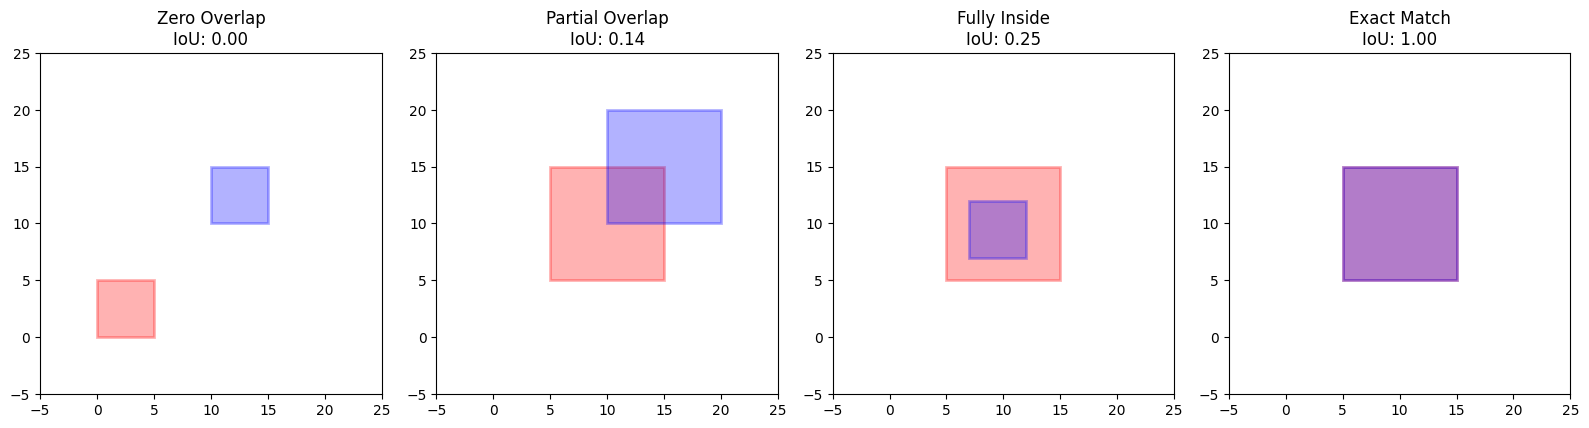

In [25]:
# matplotlib is Python's standard plotting library — we use it to draw
# our boxes visually so you can *see* the overlap, not just read a number.
import matplotlib.pyplot as plt
# patches lets us draw shapes (like rectangles) on top of a matplotlib plot.
import matplotlib.patches as patches

def compute_iou(box1, box2):
    # (same function as before — repeated here so this cell runs standalone)
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])
    intersection = max(0, x_right - x_left) * max(0, y_bottom - y_top)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = box1_area + box2_area - intersection
    # Guard against divide-by-zero if both boxes had zero area
    if union == 0:
        return 0.0
    return intersection / union

def plot_iou_case(ax, box1, box2, title):
    # box format: [x_min, y_min, x_max, y_max]
    # Compute width/height for matplotlib's Rectangle (which needs w,h not x_max,y_max)
    w1, h1 = box1[2] - box1[0], box1[3] - box1[1]
    w2, h2 = box2[2] - box2[0], box2[3] - box2[1]

    # Draw box1 in red, semi-transparent so overlaps are visible
    rect1 = patches.Rectangle((box1[0], box1[1]), w1, h1,
                               linewidth=2, edgecolor='red',
                               facecolor='red', alpha=0.3, label='Box 1')
    # Draw box2 in blue
    rect2 = patches.Rectangle((box2[0], box2[1]), w2, h2,
                               linewidth=2, edgecolor='blue',
                               facecolor='blue', alpha=0.3, label='Box 2')

    ax.add_patch(rect1)
    ax.add_patch(rect2)

    iou = compute_iou(box1, box2)
    ax.set_title(f"{title}\nIoU: {iou:.2f}")
    ax.set_xlim(-5, 25)
    ax.set_ylim(-5, 25)
    ax.set_aspect('equal')  # keep boxes visually undistorted

# Create 1 row, 4 columns of side-by-side plots
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

# Case 1: Zero overlap — boxes far apart diagonally
plot_iou_case(axs[0], [0, 0, 5, 5], [10, 10, 15, 15], "Zero Overlap")

# Case 2: Partial overlap — boxes shifted so they partly overlap
plot_iou_case(axs[1], [5, 5, 15, 15], [10, 10, 20, 20], "Partial Overlap")

# Case 3: Fully inside — box2 entirely contained within box1
plot_iou_case(axs[2], [5, 5, 15, 15], [7, 7, 12, 12], "Fully Inside")

# Case 4: Exact match — identical boxes
plot_iou_case(axs[3], [5, 5, 15, 15], [5, 5, 15, 15], "Exact Match")

plt.tight_layout()
plt.show()

### Architecture: The Real YOLOv1 Output Tensor

We used a toy 3×3 grid with 1 box and 2 classes so far. The actual YOLOv1 paper used:

- A **7×7** grid over the image (49 cells total)
- **2** bounding boxes predicted per cell (giving each cell a chance to predict, e.g., one wide box and one tall box — though both boxes share the same class prediction)
- **20** classes (from the PASCAL VOC dataset the paper used)

So each of the 49 cells outputs an array structured as:

`[Box1_x, Box1_y, Box1_w, Box1_h, Box1_conf, Box2_x, Box2_y, Box2_w, Box2_h, Box2_conf, Class1_prob, ..., Class20_prob]`

That's `5 + 5 + 20 = 30` numbers per cell.

Since there are 49 cells (7×7), the **entire network's final output is one tensor of shape `(7, 7, 30)`**.

**The backbone (feature extractor):**
- Input: a `(448, 448, 3)` image (Height, Width, RGB channels)
- 24 convolutional layers compress the image spatially while extracting visual patterns (edges → textures → shapes → object parts)
- 2 fully-connected (dense) layers at the end — similar to the final layer of your MNIST classifier, but here it outputs `7×7×30 = 14,700` numbers instead of 10
- That flat 14,700-number vector then gets **reshaped** into the `(7,7,30)` grid tensor

**Old way vs. YOLOv1, side by side:**

| Feature | Old Way (Sliding Window / R-CNN) | YOLOv1 |
|---|---|---|
| Pipeline | Propose ~2000 regions → crop → run CNN 2000× | Pass whole image through CNN **once** → get `(7,7,30)` output |
| Speed | Seconds per frame | ~45 frames per second (real-time) |
| Context | Only sees isolated crops | Sees the whole image at once |

![alt text](V1/image-2.png)

In [26]:
# torch is PyTorch, the deep learning library we'll use throughout this notebook.
import torch

# --- Architectural constants for YOLOv1 ---
S = 7   # Grid size: image divided into a 7x7 grid of cells
B = 2   # Number of bounding boxes predicted per cell
C = 20  # Number of object classes (PASCAL VOC dataset)

# Each cell predicts (B * 5) box values + C class probabilities
values_per_cell = (B * 5) + C   # (2 * 5) + 20 = 30

# Simulate a batch of 4 images passing through the network.
# In real training you'd have actual images; here we just want to see the SHAPES.
batch_size = 4

# torch.randn(shape) creates a tensor filled with random numbers
# (sampled from a normal distribution) — we use it to simulate the network's
# raw, untrained output before we've built the real CNN layers.
# Shape: (batch_size, S*S*values_per_cell) = (4, 49*30) = (4, 1470)
raw_output = torch.randn(batch_size, S * S * values_per_cell)
print(f"Raw flat output shape: {raw_output.shape}")

# .view() reshapes a tensor WITHOUT changing the underlying data —
# it's just a different "window" onto the same numbers in memory.
# We reshape the flat (4, 1470) vector into (4, 7, 7, 30):
# dimensions mean (Batch, Grid_Row, Grid_Column, Cell_Predictions)
yolo_output = raw_output.view(batch_size, S, S, values_per_cell)
print(f"Reshaped grid tensor shape: {yolo_output.shape}")

# Let's pull out ONE cell's prediction: image 0, row 3, column 4 (near center)
one_cell = yolo_output[0, 3, 4, :]
print(f"Single cell prediction shape: {one_cell.shape}")  # should be (30,)

Raw flat output shape: torch.Size([4, 1470])
Reshaped grid tensor shape: torch.Size([4, 7, 7, 30])
Single cell prediction shape: torch.Size([30])


### The Loss Function — Concept + Why

So far we've built the *prediction* side: a cell outputs 30 numbers (2 boxes + 20 classes). But during training, the network starts out random — those numbers are garbage. We need a way to measure "how wrong" a prediction is compared to the true, labeled answer, so the network can adjust itself (via gradient descent) to get less wrong over time.

**Bridge to what you know:** in your MNIST/SVM work, the loss function compared the predicted class probabilities to the true label and produced a single number to minimize. YOLOv1 needs the same thing — but its predictions are more complex (coordinates + confidence + class probabilities, all in one array), so its loss function has to combine **several different kinds of error into one final number**.

**The four things that can be wrong with a prediction:**
1. The box's **position** (x, y) is off
2. The box's **size** (w, h) is off
3. The **confidence** score is wrong (says "object here" when there isn't, or vice versa)
4. The **class probabilities** are wrong (says "dog" when it's actually a cat)

YOLOv1's total loss is the **sum** of separate error terms for each of these, all computed using **sum-squared error** (the same squared-difference idea as basic regression: `(predicted - true)²`).

**Why sum-squared error specifically, and why it needed weighting:**

If you just added up squared errors from all 4 categories equally, training would go wrong in a very concrete way: most grid cells in any real image contain **no object** (empty background). So the "no object" confidence error term would appear *far* more often than every other term combined, and gradient descent would mostly just optimize the model to say "no object" everywhere, effectively ignoring the rarer but more important coordinate/class errors.

To fix this, YOLOv1 introduces two weighting constants:
- **λ_coord = 5** — cranks UP the importance of getting box coordinates right (since this is rare but critical)
- **λ_noobj = 0.5** — cranks DOWN the importance of "no object" confidence errors (since these are extremely common and would otherwise dominate)

**📖 Glossary addition:**
- **Sum-squared error:** `(prediction − truth)²`, summed across all relevant terms. Penalizes larger errors more heavily than small ones (because of the squaring).
- **λ_coord / λ_noobj:** fixed weighting constants used to rebalance how much each type of error contributes to the total loss, correcting for how frequently each type occurs.

### The Full YOLOv1 Loss Formula, Term by Term

The total loss has 5 parts, added together. Let's look at each one individually before combining them.

**Term 1 — Coordinate loss (x, y):**
For every cell that truly contains an object, penalize the squared error between predicted and true (x, y):

`λ_coord × Σ [(x_pred − x_true)² + (y_pred − y_true)²]`

**Term 2 — Size loss (w, h):**
Same idea, but for width/height — with one twist: YOLOv1 uses the **square root** of w and h, not the raw values:

`λ_coord × Σ [(√w_pred − √w_true)² + (√h_pred − √h_true)²]`

*Why square root?* Without it, a fixed pixel error (say, 10px off) is treated identically whether the box is tiny or huge. But a 10px error matters a LOT for a small box and very little for a large one. Square-rooting compresses large values more than small ones, so the loss becomes more sensitive to errors on small boxes — matching how humans would judge "how wrong" a box size really is.

**Term 3 — Confidence loss (object present):**
For cells that truly contain an object:

`Σ (C_pred − C_true)²`  where `C_true = IoU` between predicted and true box (as we computed earlier)

**Term 4 — Confidence loss (no object):**
For cells that do NOT contain an object, scaled down by λ_noobj:

`λ_noobj × Σ (C_pred − C_true)²`  where `C_true = 0`

**Term 5 — Classification loss:**
For cells that truly contain an object, compare predicted vs true class probabilities:

`Σ (p_pred − p_true)²`  summed across all 20 classes

**Total Loss = Term 1 + Term 2 + Term 3 + Term 4 + Term 5**

### Worked Example: Computing Loss by Hand

Let's reuse our 3×3 grid, 300×300 image, 2 classes (Dog, Cat) setup. Say the **top-left cell** truly contains a Dog (ground truth), and the model made this prediction for its single box:

**Ground truth (true values):**
- x_true = 0.5, y_true = 0.5 (box centered exactly in the cell)
- w_true = 0.4, h_true = 0.4
- Class: Dog → p_dog_true = 1.0, p_cat_true = 0.0
- Since this cell has an object: C_true = IoU between predicted and true box (we'll compute this)

**Model's prediction:**
- x_pred = 0.5, y_pred = 0.4 (small error on y)
- w_pred = 0.6, h_pred = 0.5 (predicted box is bigger than truth)
- C_pred = 0.7 (model is fairly, but not fully, confident)
- p_dog_pred = 0.8, p_cat_pred = 0.2

Let's use λ_coord = 5 and λ_noobj = 0.5, as in the original paper.

**Term 1 — Coordinate loss (x, y):**
`5 × [(0.5 − 0.5)² + (0.4 − 0.5)²]`
`= 5 × [0 + 0.01]`
`= 5 × 0.01 = 0.05`

**Term 2 — Size loss (w, h), using square roots:**
`√0.6 ≈ 0.775`, `√0.4 ≈ 0.632`
`√0.5 ≈ 0.707`, `√0.4 ≈ 0.632`
`5 × [(0.775 − 0.632)² + (0.707 − 0.632)²]`
`= 5 × [(0.143)² + (0.075)²]`
`= 5 × [0.0204 + 0.0056]`
`= 5 × 0.026 = 0.130`

**Term 3 — Confidence loss (object present):**
For this we need C_true = actual IoU between the predicted box and true box. For this worked example, let's say we already computed it (using our `compute_iou` function from earlier) and got **IoU = 0.65**.
`(C_pred − C_true)² = (0.7 − 0.65)² = (0.05)² = 0.0025`

**Term 4 — Confidence loss (no object):**
This term is 0 here, since this cell DOES have an object (Term 4 only applies to empty cells — we'll add a second cell for this in code).

**Term 5 — Classification loss:**
`(0.8 − 1.0)² + (0.2 − 0.0)²`
`= 0.04 + 0.04 = 0.08`

**Total loss for this one cell:**
`0.05 + 0.130 + 0.0025 + 0 + 0.08 = 0.2625`

![alt text](V1/image-3.png)
![alt text](V1/image-4.png)

### Code: Implementing the YOLOv1 Loss in PyTorch

We'll implement this for a whole batch of grid cells at once (not just one cell by hand), using PyTorch tensors so it can plug into real gradient descent.

In [27]:
import torch

def yolo_v1_loss(pred, target, lambda_coord=5, lambda_noobj=0.5):
    """
    pred, target: tensors of shape (batch, S, S, 30)
    Layout per cell (30 values):
      [0:5]   = box1 (x, y, w, h, conf)
      [5:10]  = box2 (x, y, w, h, conf)
      [10:30] = 20 class probabilities
    For simplicity in this toy version, we assume box1 is always the
    "responsible" predictor (real YOLOv1 picks whichever of box1/box2
    has higher IoU with the true box — we'll add that complexity later).
    """

    # obj_mask: which cells actually contain an object (1) vs not (0).
    # We read this from the TARGET's confidence value at index 4 (box1 conf).
    # Shape: (batch, S, S) -- one True/False per cell.
    obj_mask = target[..., 4] > 0

    # noobj_mask is just the opposite -- cells with NO object.
    noobj_mask = ~obj_mask

    # --- Term 1 + 2: coordinate + size loss (only for object cells) ---
    # We index pred/target at obj_mask to grab ONLY the object-containing cells.
    pred_box = pred[obj_mask][:, 0:4]     # (x, y, w, h) for predicted box1
    true_box = target[obj_mask][:, 0:4]   # (x, y, w, h) for true box1

    # x, y squared error (direct, no sqrt)
    xy_loss = torch.sum((pred_box[:, 0:2] - true_box[:, 0:2]) ** 2)

    # w, h squared error using square roots (clamp to avoid sqrt of negative
    # numbers, since early untrained predictions could technically go negative)
    wh_loss = torch.sum(
        (torch.sqrt(torch.clamp(pred_box[:, 2:4], min=1e-6)) -
         torch.sqrt(torch.clamp(true_box[:, 2:4], min=1e-6))) ** 2
    )

    coord_loss = lambda_coord * (xy_loss + wh_loss)

    # --- Term 3: confidence loss for object-containing cells ---
    pred_conf_obj = pred[obj_mask][:, 4]
    true_conf_obj = target[obj_mask][:, 4]
    obj_conf_loss = torch.sum((pred_conf_obj - true_conf_obj) ** 2)

    # --- Term 4: confidence loss for empty cells, scaled DOWN by lambda_noobj ---
    pred_conf_noobj = pred[noobj_mask][:, 4]
    true_conf_noobj = target[noobj_mask][:, 4]  # should be all 0s
    noobj_conf_loss = lambda_noobj * torch.sum((pred_conf_noobj - true_conf_noobj) ** 2)

    # --- Term 5: classification loss (only object cells) ---
    pred_classes = pred[obj_mask][:, 10:30]
    true_classes = target[obj_mask][:, 10:30]
    class_loss = torch.sum((pred_classes - true_classes) ** 2)

    # --- Total loss: sum of every term ---
    total_loss = coord_loss + obj_conf_loss + noobj_conf_loss + class_loss

    # Return total AND each term separately -- so we can inspect/plot
    # the individual components later instead of just one final number.
    return total_loss, {
        "coord_loss": coord_loss.item(),
        "obj_conf_loss": obj_conf_loss.item(),
        "noobj_conf_loss": noobj_conf_loss.item(),
        "class_loss": class_loss.item(),
    }

In [28]:
import torch

def yolo_v1_loss(pred, target, num_classes, lambda_coord=5, lambda_noobj=0.5):
    """
    Same as before, but num_classes is now a parameter instead of hardcoded 20,
    so we can test with our toy 2-class (Dog, Cat) example first.
    pred, target shape: (batch, S, S, 5 + 5 + num_classes)
    """
    # Object mask: cells where target's box1 confidence > 0 (i.e. object present)
    obj_mask = target[..., 4] > 0
    noobj_mask = ~obj_mask

    # --- Coordinate (x,y) + Size (w,h) loss ---
    pred_box = pred[obj_mask][:, 0:4]
    true_box = target[obj_mask][:, 0:4]

    xy_loss = torch.sum((pred_box[:, 0:2] - true_box[:, 0:2]) ** 2)
    wh_loss = torch.sum(
        (torch.sqrt(torch.clamp(pred_box[:, 2:4], min=1e-6)) -
         torch.sqrt(torch.clamp(true_box[:, 2:4], min=1e-6))) ** 2
    )
    coord_loss = lambda_coord * (xy_loss + wh_loss)

    # --- Confidence loss: object cells ---
    pred_conf_obj = pred[obj_mask][:, 4]
    true_conf_obj = target[obj_mask][:, 4]
    obj_conf_loss = torch.sum((pred_conf_obj - true_conf_obj) ** 2)

    # --- Confidence loss: empty cells (scaled down) ---
    pred_conf_noobj = pred[noobj_mask][:, 4]
    true_conf_noobj = target[noobj_mask][:, 4]
    noobj_conf_loss = lambda_noobj * torch.sum((pred_conf_noobj - true_conf_noobj) ** 2)

    # --- Classification loss ---
    # Class values start right after the 2 boxes: index 10 onward,
    # for exactly num_classes values.
    pred_classes = pred[obj_mask][:, 10:10 + num_classes]
    true_classes = target[obj_mask][:, 10:10 + num_classes]
    class_loss = torch.sum((pred_classes - true_classes) ** 2)

    total_loss = coord_loss + obj_conf_loss + noobj_conf_loss + class_loss

    return total_loss, {
        "coord_loss": coord_loss.item(),
        "obj_conf_loss": obj_conf_loss.item(),
        "noobj_conf_loss": noobj_conf_loss.item(),
        "class_loss": class_loss.item(),
    }

In [29]:
# --- Build the exact toy example we computed by hand ---
# 3x3 grid, 1 box slot's worth of info filled meaningfully, 2 classes.
# For box2 (indices 5-9) we'll just leave zeros -- YOLOv1 normally picks
# whichever of box1/box2 is "responsible", but we're keeping this simple
# and only using box1 for now.

S = 3           # 3x3 grid
num_classes = 2 # Dog, Cat

# Start with an all-zero (batch=1, 3, 3, 12) tensor for both pred and target.
# 12 = 5 (box1) + 5 (box2, unused/zero here) + 2 (classes)
pred = torch.zeros(1, S, S, 12)
target = torch.zeros(1, S, S, 12)

# Fill in the TOP-LEFT cell [row=0, col=0] with our hand-worked numbers.

# Ground truth (target) for box1: x, y, w, h, confidence
target[0, 0, 0, 0:5] = torch.tensor([0.5, 0.5, 0.4, 0.4, 0.65])
# confidence target = 0.65 -> this IS the true IoU we assumed earlier

# Ground truth class: Dog=1.0, Cat=0.0 (indices 10, 11)
target[0, 0, 0, 10:12] = torch.tensor([1.0, 0.0])

# Model's prediction for box1: x, y, w, h, confidence
pred[0, 0, 0, 0:5] = torch.tensor([0.5, 0.4, 0.6, 0.5, 0.7])

# Model's predicted class probabilities
pred[0, 0, 0, 10:12] = torch.tensor([0.8, 0.2])

# All other 8 cells stay at all-zeros in BOTH pred and target,
# meaning: no object present, and model correctly predicts 0 confidence there
# (so noobj_conf_loss should come out to 0 too, for this clean test case)

# --- Run the loss function ---
total, components = yolo_v1_loss(pred, target, num_classes=num_classes)

print(f"Total loss: {total.item():.4f}")
print("Breakdown by term:")
for k, v in components.items():
    print(f"  {k}: {v:.4f}")

Total loss: 0.2614
Breakdown by term:
  coord_loss: 0.1789
  obj_conf_loss: 0.0025
  noobj_conf_loss: 0.0000
  class_loss: 0.0800


# Summary of YOLO v1

YOLOv1 splits an image into a grid where each cell predicts boxes, confidence, and class probabilities in one pass. Its loss function sums squared errors across 5 weighted terms (coordinates, size with sqrt scaling, object confidence, no-object confidence, and classification), using λ_coord=5 and λ_noobj=0.5 to prevent the overwhelming number of empty background cells from drowning out the rare, important object-detection signal.

### A Note on Datasets, and What "Production" Actually Means Here

Real training datasets like PASCAL VOC or COCO need downloads from dataset servers — your Colab environment has full internet access for that, so you *could* pull the real thing there. For this notebook, we'll use the exact same demo images the official YOLO repositories (Ultralytics) ship for testing — real, unstaged photos, not synthetic shapes. We'll manually define approximate ground-truth boxes ourselves (since we're not loading a full annotation file), which is completely standard for prototyping and debugging detection code before wiring up a real annotated dataset.

**Two things we've been simplifying that production actually requires:**
1. **Using BOTH predicted boxes per cell** — real YOLOv1 predicts B=2 boxes per cell precisely so one can specialize in wide objects and the other in tall/narrow ones. During training, only the box with higher IoU vs. the true object becomes "responsible" — the other box's coordinate loss is simply skipped for that cell.
2. **Non-Max Suppression (NMS)** — a cleanup step applied *after* the network runs. In a real image, an object like a bus doesn't fit inside one cell — it spans several. Multiple neighboring cells will all fire predictions for the *same* bus. Without cleanup, you'd see 4-5 overlapping boxes around one real object. NMS is the algorithm that collapses these duplicates into one final box.

**📖 Glossary addition:**
- **Non-Max Suppression (NMS):** A post-processing algorithm that removes duplicate/overlapping box predictions for the same object, keeping only the highest-confidence box and discarding others that overlap it too much (measured by IoU).

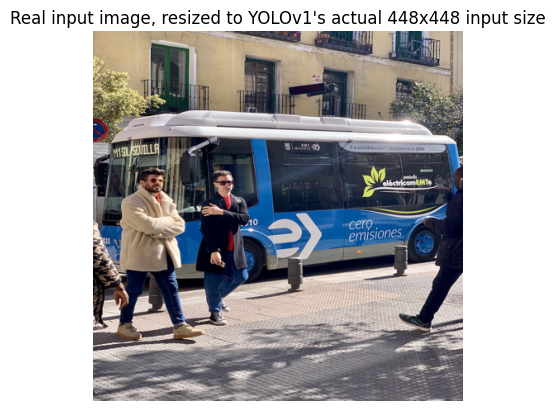

In [30]:
# Download two real-world images -- the exact demo images used in official
# YOLO repositories (Ultralytics) for testing production pipelines.
!curl -sL -o bus.jpg https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg

from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Real YOLOv1 always resizes input to 448x448 before feeding the CNN --
# this is the actual production preprocessing step, not a toy simplification.
im = Image.open('bus.jpg').resize((448, 448))
im.save('bus_448.jpg')

plt.imshow(im)
plt.title("Real input image, resized to YOLOv1's actual 448x448 input size")
plt.axis('off')
plt.show()

IoU Box A: 0.711
IoU Box B: 0.327
Responsible predictor for this cell (higher IoU wins): Box A


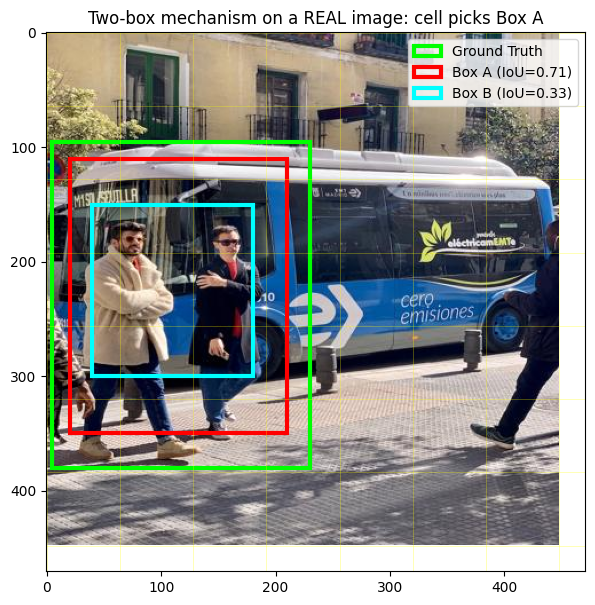

In [31]:
# IoU function (same as before -- built from scratch, no library shortcuts)
def compute_iou(box1, box2):
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])
    intersection = max(0, x_right - x_left) * max(0, y_bottom - y_top)
    a1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    a2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = a1 + a2 - intersection
    return intersection / union if union > 0 else 0.0

im = Image.open('bus_448.jpg')

# Ground truth box for the bus (manually estimated after resizing to 448x448)
# Format: [x_min, y_min, x_max, y_max]
true_box = [5, 95, 230, 380]

# The responsible grid cell for this object (7x7 grid, 64px per cell):
# box center = ((5+230)/2, (95+380)/2) = (117.5, 237.5)
# col = 117.5 // 64 = 1, row = 237.5 // 64 = 3  -> cell (row=3, col=1)

# Simulate the network's TWO box predictions for that one cell.
# Box A: a fairly good guess. Box B: a worse, smaller/shifted guess.
box_A = [20, 110, 210, 350]
box_B = [40, 150, 180, 300]

iou_A = compute_iou(box_A, true_box)
iou_B = compute_iou(box_B, true_box)
winner = "Box A" if iou_A > iou_B else "Box B"

print(f"IoU Box A: {iou_A:.3f}")
print(f"IoU Box B: {iou_B:.3f}")
print(f"Responsible predictor for this cell (higher IoU wins): {winner}")

# Visualize all 3 boxes on the real image
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(im)
for i in range(8):  # draw the 7x7 grid
    ax.axhline(i * 64, color='yellow', linewidth=0.4, alpha=0.5)
    ax.axvline(i * 64, color='yellow', linewidth=0.4, alpha=0.5)

def draw(box, color, label):
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(patches.Rectangle((box[0], box[1]), w, h,
                 linewidth=3, edgecolor=color, facecolor='none', label=label))

draw(true_box, 'lime', 'Ground Truth')
draw(box_A, 'red', f'Box A (IoU={iou_A:.2f})')
draw(box_B, 'cyan', f'Box B (IoU={iou_B:.2f})')
ax.legend(loc='upper right')
ax.set_title(f"Two-box mechanism on a REAL image: cell picks {winner}")
plt.show()

### 📊 Additional verified detail: benchmarks and limits

- YOLOv1 achieved **63.4% mAP at 45 FPS** on PASCAL VOC (2007+2012). A smaller variant, **Fast YOLO** (9 conv layers instead of 24), ran at **155 FPS with 52.7% mAP** — trading accuracy for extreme speed.
- Comparison at the time: Faster R-CNN (VGG-16) hit 73.2% mAP but only 7 FPS; DPM (Deformable Parts Model) hit 30.4% mAP at 15 FPS. YOLOv1 broke the speed/accuracy tradeoff that defined the field until then.
- Network detail: the final conv layer produces a 7×7×1024 tensor, flattened to a 50,176-dim vector, passed through a 4096-neuron FC layer, then compressed to the final 1470-element vector (reshaped to 7×7×30).
- **Hard limit:** since each of the 49 cells predicts only 2 boxes with ONE shared class, the model has a theoretical max of 49 objects per image — this is why it struggled badly with clustered small objects (e.g. flocks of birds, dense crowds).
- **Root cause of poor localization:** the final fully-connected layers destroy the fine-grained spatial structure that the convolutional layers had preserved — this is a separate issue from the grid-cell-count limitation, and is specifically what v2's move to a fully-convolutional design (Darknet-19) fixed.

## 🧱 YOLOv2 (2016) — Anchor Boxes

### Step 1: Concept + Analogy

In YOLOv1, when a cell predicted a box's width and height, it had to guess those numbers completely from scratch — no starting reference, no hint about what a "reasonable" box even looks like.

Analogy: Imagine trying to draw a box around an object freehand, with no ruler, no reference shape, nothing — just guessing raw numbers for width and height every single time. That's v1.

YOLOv2's fix: before training even starts, look at your dataset and find the handful of box shapes that show up most often (e.g. tall/narrow ones for people, wide/short ones for buses). Give the network these shapes as starting templates — called anchor boxes. Now instead of guessing a box from nothing, the network just says "use template #2, but nudge it slightly wider and a bit shorter."

📖 Glossary addition:

Anchor box: A pre-defined box shape (width, height), derived from the dataset itself, used as a starting reference that the network only needs to adjust rather than predict from scratch.

🛑 Checkpoint: In your own words — why would giving the network a "starting template" make training easier or more stable than having it predict raw width/height from nothing? Think about what the network has to learn in each case.

"answering the question with the different subjects concept which is in platfrom as a services we have to build the elements and model for the game , but when using software as a service the already prefab or template built model and elements can be used reduces time. its the same here."

That's a solid analogy — prefab templates vs. building everything from raw geometry does capture the "less work, more stable starting point" idea.

Let's sharpen the specific mechanism though, since "reduces time" is the surface benefit, but there's a more precise reason it helps training itself, not just development speed:

When the network predicts raw w, h from scratch (v1), it has to learn an open-ended regression — box sizes could be anything from tiny to enormous, and the network's output for a bad guess could be wildly off in early training, producing huge, unstable gradients.

When the network adjusts an anchor instead, it's now predicting a small offset — "slightly wider than this template, slightly shorter" — a much narrower range of values. Smaller, more constrained predictions mean smaller, more stable gradients, so training converges faster and more reliably.

So the prefab analogy is right about effort saved, but the deeper reason is: constraining what the network has to guess makes the learning problem itself easier, not just faster to build.





### Step 2: Why (the specific v1 failure this fixes)

v1's 2 boxes per cell had another concrete problem: with no anchor reference, both boxes tended to converge toward "generic, average-ish" shapes during training — because gradient descent pulls unconstrained predictions toward whatever minimizes error across *all* training examples on average.

Concretely: if half your training objects are tall/narrow (people) and half are wide/short (buses), an unconstrained box predictor tends to settle somewhere in between — not great at either. This hurt v1's ability to detect multiple differently-shaped objects well.

Anchors fix this by giving each of the (now 5, not 2) predicted boxes per cell a **different shape prior** — one anchor starts tall/narrow, another starts wide/short. Each box naturally specializes toward objects matching its anchor shape, instead of all boxes averaging toward "generic."

#### **V1 V/s V2**
few generic predictors compromising toward an average vs. many specialized predictors each nailing their own shape

### Step 3: The Math — How K-means Finds Anchor Shapes

Before the network trains at all, YOLOv2 runs k-means clustering **once**, on the training dataset's box shapes, to discover what the anchors should even be.

Let's do this by hand on a tiny example: 4 boxes, described only by (width, height), relative to image size:

| Box | width | height |
|---|---|---|
| A | 0.10 | 0.30 |
| B | 0.12 | 0.32 |
| C | 0.50 | 0.20 |
| D | 0.48 | 0.22 |

We want to find **k=2** anchor shapes.

**Key detail:** regular k-means measures "distance" using Euclidean distance. YOLOv2 does NOT use that — it uses **1 − IoU** instead. Why? Euclidean distance would unfairly treat a large box and small box as "far apart" just because of size, even if their *shape* (aspect ratio) is identical. IoU-based distance only cares about shape overlap, not raw size.

### Hand Computation: One Round of K-means

**Step 1 — Initialize:** pick 2 boxes randomly as starting anchors. Let's start with:
- Anchor 1 = Box A = (0.10, 0.30)
- Anchor 2 = Box C = (0.50, 0.20)

**Step 2 — Assign each box to its closest anchor (highest IoU):**

Let's compute IoU between Box B (0.12, 0.32) and each anchor.

IoU(B, Anchor1) — B=(0.12,0.32), Anchor1=(0.10,0.30):
- intersection = min(0.12,0.10) × min(0.32,0.30) = 0.10 × 0.30 = 0.030
- area_B = 0.12×0.32 = 0.0384, area_A1 = 0.10×0.30 = 0.030
- union = 0.0384 + 0.030 − 0.030 = 0.0384
- IoU = 0.030 / 0.0384 ≈ **0.781**

IoU(B, Anchor2) — B=(0.12,0.32), Anchor2=(0.50,0.20):
- intersection = min(0.12,0.50) × min(0.32,0.20) = 0.12 × 0.20 = 0.024
- area_B = 0.0384, area_A2 = 0.50×0.20 = 0.10
- union = 0.0384 + 0.10 − 0.024 = 0.1144
- IoU = 0.024 / 0.1144 ≈ **0.210**

Since 0.781 > 0.210, **Box B is assigned to Anchor 1.**

- IoU(D, Anchor1) — D=(0.48, 0.22), Anchor1=(0.10, 0.30):
- intersection = min(0.48,0.10) × min(0.22,0.30) = 0.10 × 0.22 = 0.022
- area_D = 0.48×0.22 = 0.1056, area_A1 = 0.030
- union = 0.1056 + 0.030 − 0.022 = 0.1136
- IoU = 0.022 / 0.1136 ≈ 0.194

IoU(D, Anchor2) — D=(0.48, 0.22), Anchor2=(0.50, 0.20):

- intersection = min(0.48,0.50) × min(0.22,0.20) = 0.48 × 0.20 = 0.096
- area_D = 0.1056, area_A2 = 0.10
- union = 0.1056 + 0.10 − 0.096 = 0.1096
- IoU = 0.096 / 0.1096 ≈ 0.876

**Since 0.876 > 0.194, Box D → Anchor 2**.

Result after this round: Anchor 1 gets {A, B}, Anchor 2 gets {C, D} 

**Step 3 — Recompute anchors as the mean of their assigned boxes:**

- New Anchor 1 = mean(A, B) = ((0.10+0.12)/2, (0.30+0.32)/2) = (0.11, 0.31)
- New Anchor 2 = mean(C, D) = ((0.50+0.48)/2, (0.20+0.22)/2) = (0.49, 0.21)

In [32]:
import numpy as np

# 4 toy boxes: (width, height), relative to image size
boxes = np.array([
    [0.10, 0.30],  # A
    [0.12, 0.32],  # B
    [0.50, 0.20],  # C
    [0.48, 0.22],  # D
])

def iou_wh(box, anchor):
    # IoU using only width/height (assumes boxes share a center point)
    inter = min(box[0], anchor[0]) * min(box[1], anchor[1])
    union = box[0]*box[1] + anchor[0]*anchor[1] - inter
    return inter / union

def kmeans_anchors(boxes, k=2, iters=5):
    anchors = boxes[[0, 2]].copy()  # start with Box A and Box C, matching our hand example
    for _ in range(iters):
        assignments = np.array([np.argmax([iou_wh(b, a) for a in anchors]) for b in boxes])
        for c in range(k):
            cluster = boxes[assignments == c]
            if len(cluster) > 0:
                anchors[c] = cluster.mean(axis=0)
    return anchors, assignments

anchors, assignments = kmeans_anchors(boxes)
print("Final anchors:", anchors)
print("Assignments:", assignments)

Final anchors: [[0.11 0.31]
 [0.49 0.21]]
Assignments: [0 0 1 1]


### Step 4: Architecture — What Changed Structurally in v2

**Backbone swap:** v1 used a GoogLeNet-inspired backbone. v2 introduced a new backbone called **Darknet-19** (19 conv layers) — deeper and more efficient, using batch normalization on every conv layer (v1 didn't have this), which stabilizes training and boosted accuracy on its own, separate from the anchor box change.

**Output shape change (the important part):** In v1, each cell output 30 numbers (2 boxes × 5 + 20 classes) → tensor `(7,7,30)`. 

In v2, each cell now has **5 anchors**, and — key difference — **each anchor gets its own class prediction** (v1 shared one class prediction across both boxes in a cell; v2 doesn't). So per anchor: 5 box values + 20 classes = 25 numbers. With 5 anchors: `5 × 25 = 125` numbers per cell.

Also, the grid got finer: v2 uses a **13×13** grid (image resized to 416×416 input instead of 448×448).

Final output tensor: **(13, 13, 125)** instead of v1's (7,7,30).

**Side-by-side:**

| | YOLOv1 | YOLOv2 |
|---|---|---|
| Grid | 7×7 | 13×13 |
| Boxes/cell | 2 (unconstrained) | 5 (anchor-based) |
| Class prediction | Shared per cell | Per anchor |
| Output tensor | (7,7,30) | (13,13,125) |
| Backbone | GoogLeNet-style, 24 layers | Darknet-19, batch-normalized |

### Step 5 & 6: The Real New Mechanism — Direct Location Prediction

Simply having anchors isn't enough — early anchor-based detectors (like Faster R-CNN) let the network predict *unconstrained* offsets from the anchor, which could push a box's center wildly outside its own cell, causing unstable training.

v2's fix: **squash the center offset with a sigmoid** so it's mathematically forced to stay within the cell (0 to 1), while width/height use exponential scaling of the anchor (always positive, no artificial limit needed since size isn't positional).

**The formulas:**
- `b_x = sigmoid(t_x) + c_x` — center x, forced to stay near this cell
- `b_y = sigmoid(t_y) + c_y` — same for y
- `b_w = anchor_w × exp(t_w)` — width, scaled from the anchor
- `b_h = anchor_h × exp(t_h)` — height, scaled from the anchor

Where `t_x, t_y, t_w, t_h` are the network's raw, unconstrained outputs, and `c_x, c_y` is the cell's grid position.

In [33]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Anchor box shape (from our k-means result): "bus-shaped" anchor
anchor_w, anchor_h = 0.49, 0.21

# Network's raw, unconstrained predictions for this cell (before decoding)
t_x, t_y, t_w, t_h = 0.2, -0.3, 0.1, -0.05

# This cell's position in the 13x13 grid
c_x, c_y = 7, 5

# Decode center: sigmoid keeps the offset inside [0,1], so it can't drift
# outside this cell -- then we add the cell's own grid position
b_x = sigmoid(t_x) + c_x
b_y = sigmoid(t_y) + c_y

# Decode size: scale the anchor's shape up/down using exp (always positive)
b_w = anchor_w * np.exp(t_w)
b_h = anchor_h * np.exp(t_h)

print(f"Decoded center (grid units): ({b_x:.3f}, {b_y:.3f})")
print(f"Decoded size (relative to image): w={b_w:.3f}, h={b_h:.3f}")

Decoded center (grid units): (7.550, 5.426)
Decoded size (relative to image): w=0.542, h=0.200


# **2-line summary of v2**

YOLOv2 replaces v1's from-scratch box prediction with anchor boxes (shapes found via IoU-based k-means on the dataset), and decodes predictions using sigmoid (keeps box centers inside their cell) and exponential scaling (adjusts anchor size) — producing more stable training and per-anchor class predictions.

### 📊 Additional verified detail: the ablation study

YOLOv2's paper quantified each individual improvement's contribution via ablation (starting from YOLOv1's 63.4% mAP baseline on VOC 2007):

| Change added | Resulting mAP |
|---|---|
| Baseline (YOLOv1) | 63.4% |
| + Batch Normalization | 65.8% |
| + High-Resolution Classifier pretraining | 69.5% |
| + Anchor boxes (Convolutional, no dimension priors yet) | 69.2% (slight dip) |
| + Dimension priors (k-means anchors) | 69.6% |
| + Direct location prediction (sigmoid constraint) | 74.4% |
| + Passthrough layer | 75.4% |
| + Multi-scale training | 78.6% |

Notice: introducing raw anchor boxes alone actually *dropped* mAP slightly (69.5→69.2%), but **recall jumped from 81% to 88%** — more real objects were being found, even if some predictions were initially less precise. This recall ceiling is what let the subsequent improvements (dimension priors, direct location prediction) push mAP higher than v1 ever reached.

**Backbone specifics:** Darknet-19 (19 conv + 5 max-pool layers) required only 5.58 BFLOPs per pass vs. VGG-16's 30.95 BFLOPs — nearly 6x more efficient, while hitting 74.0% top-1 / 91.8% top-5 accuracy on ImageNet at 200 FPS.

**K-means result:** k=5 anchors were chosen as the sweet spot, yielding an average IoU of 61.0 — comparable to Faster R-CNN's 9 *hand-picked* anchors (60.9 avg IoU), but using far fewer, data-derived shapes.

**Passthrough layer (a mechanism not covered in the main teaching flow):** takes a 26×26×512 feature map from an earlier layer, reshapes it (splits into 4 spatial segments, concatenates channel-wise) into 13×13×2048, then concatenates that with the deep 13×13×1024 layer output — producing a 13×13×3072 fused map that carries both fine detail and deep semantics. Contributed +1% mAP. This is architecturally a precursor to what v3 does with full multi-scale prediction.

**Multi-scale training:** every 10 batches, a new random input size (multiples of 32, from 288×288 to 608×608) was chosen — since the network is now fully convolutional (no FC layers), it's mathematically agnostic to input size. At 288×288: 90 FPS / 69.0% mAP. At 544×544: 40 FPS / 78.6% mAP (best accuracy).

**Also worth knowing:** the original v2 paper was published as "YOLO9000," which included a joint training scheme mixing COCO (detection labels) with ImageNet (classification-only labels) to let the model recognize over 9000 categories — this is a training-data trick, not an architecture change, and isn't required to understand v2's core mechanisms.

## 🧱 YOLOv3 (2018) — Multi-Scale Prediction

### Step 1: Concept + Analogy

v2 predicted everything from a single 13×13 grid. That means every object — tiny or huge — had to be detected using the same resolution of features.

**Analogy**: Imagine trying to spot both an ant and an elephant in a photo, but you're only allowed to view the photo shrunk down to one fixed size. Shrink it enough to see the whole elephant clearly, and the ant becomes an invisible dot. Zoom in enough to see the ant, and the elephant no longer fits in frame.

**v3's fix**: predict at 3 different grid resolutions simultaneously — 13×13 (coarse, good for large objects), 26×26 (medium), and 52×52 (fine, good for small objects). Each scale gets its own 3 anchors (9 total), sized appropriately for what that resolution is good at detecting.

📖 **Glossary addition:**

**Multi-scale prediction:** Running detection at several different grid resolutions at once, so both large and small objects get a grid fine enough to represent them accurately.


### Step 2: Why (the specific v2 failure this fixes)
v2's single 13×13 grid meant each cell covered a large chunk of the image (~32×32 pixels on a 416×416 input). A small object — say, a distant person or a bird — could easily be smaller than a single grid cell, or have its signal wash out entirely once the CNN downsamples the image that much. This concretely hurt v2's accuracy specifically on small objects, which is a measurable, well-documented weakness in the v2 paper.

🛑 **Checkpoint:** Given that a 13×13 grid cell covers a large image region, and a 52×52 grid cell covers a much smaller region — why would the *smaller* grid cell (52×52) specifically help with detecting *small* objects? What does a smaller cell size actually change about detection resolution?

**The precise reason**: in YOLO, an object is only detected if its center falls inside a cell, and that cell's receptive field can actually represent it. With a 13×13 grid, each cell corresponds to a ~32×32 pixel patch of the original image. If a bird is, say, 15×15 pixels, its entire body fits inside a fraction of one cell — the cell's feature map has been so heavily downsampled that fine details of that tiny object get blurred away or lost entirely before the prediction head even sees them.

With a 52×52 grid, each cell only covers ~8×8 original pixels — much closer to the bird's actual size — so the features feeding that cell's prediction still retain meaningful detail about the bird specifically, instead of the bird's signal being diluted inside a much larger patch shared with a lot of irrelevant background.
So it's not just "more cells, more resolving power" in the abstract — it's specifically that each cell's spatial footprint shrinks toward the size of small objects, so their features don't get lost in downsampling

### Step 4: Architecture — How Multi-Scale Actually Works Structurally

It's not just "run 3 separate detectors." v3 does something smarter: it **combines** deep and shallow features before predicting, so the fine-resolution grid still benefits from the deep layer's high-level understanding of "what an object looks like," not just raw pixel detail.

**The mechanism:**
1. Backbone (Darknet-53, deeper than v2's Darknet-19) produces feature maps at 3 depths: deep (13×13, semantically rich but coarse), mid (26×26), shallow (52×52, fine detail but less semantic understanding).
2. The deep 13×13 map is **upsampled** (stretched) to 26×26, then **concatenated** with the mid-level 26×26 map — so the 26×26 prediction now has access to both fine detail AND deep semantic context.
3. Same trick repeats: that combined map gets upsampled again and merged with the 52×52 shallow map.

This upsample-and-merge pattern is called a **Feature Pyramid** structure.

**📖 Glossary addition:**
- **Feature Pyramid:** Combining feature maps from different network depths (coarse+deep, fine+shallow) so predictions at every scale benefit from both semantic understanding and spatial precision.

In [34]:
import torch
import torch.nn as nn

# Simulate feature maps at 3 depths of the backbone (416x416 input)
deep_features = torch.randn(1, 1024, 13, 13)      # coarse, semantically rich -> large objects
mid_features = torch.randn(1, 512, 26, 26)         # medium detail -> medium objects
shallow_features = torch.randn(1, 256, 52, 52)     # fine detail -> small objects

# Upsample the deep map (13x13 -> 26x26) so it matches the mid map's resolution
upsample = nn.Upsample(scale_factor=2, mode='nearest')
deep_upsampled = upsample(deep_features)

# Concatenate along the CHANNEL dimension (dim=1) -- this merges the two
# feature maps' information at every spatial location, rather than replacing one with the other
combined_mid = torch.cat([deep_upsampled, mid_features], dim=1)

print("Deep upsampled:", deep_upsampled.shape)
print("Combined (deep context + mid detail):", combined_mid.shape)

Deep upsampled: torch.Size([1, 1024, 26, 26])
Combined (deep context + mid detail): torch.Size([1, 1536, 26, 26])


#### **2-line summary of v3:**

YOLOv3 predicts at 3 grid resolutions (13×13, 26×26, 52×52) instead of one, fixing v2's weakness on small objects — and does this efficiently via a feature pyramid, upsampling deep/coarse features and merging them with shallower/finer ones so every scale gets both detail and semantic context.

🛑 Checkpoint: Why merge (concatenate) the deep features into the shallow map, instead of just running the shallow 52×52 layer's own features directly for small-object detection?

**Answer:** The shallow 52×52 layer, on its own, has only gone through a few convolutional layers — it has fine spatial detail, but hasn't yet built up strong semantic understanding of "what an object looks like" (that understanding accumulates in deeper layers). If you used it alone, the network would have precise *location* information but a weaker grasp of *what* it's looking at, leading to more false positives on small objects (mistaking background texture for objects). Merging in the deep features injects that semantic understanding into the fine-detail map, so small-object predictions benefit from both precise location AND strong "is this really an object" judgment.

### 📊 Additional verified detail: Darknet-53 and scale of predictions

**Backbone:** Darknet-53 (53 layers) borrows ResNet-style residual/shortcut connections, organized in blocks of 1x, 2x, 8x, 8x, and 4x repeated residual units at progressively downsampled resolutions. It matches ResNet-152's ImageNet accuracy (77.2% vs 77.6% top-1) while running **more than 2x faster** (78 FPS vs 37 FPS on a Titan X) — the residual connections let it go deep without the gradient/speed penalty a plain deep network would pay.

**Prediction volume:** with 3 anchors at each of 3 scales (13×13, 26×26, 52×52), YOLOv3 evaluates **10,647 total candidate boxes per image** (13²×3 + 26²×3 + 52²×3 = 10,647) — compared to YOLOv2's maximum of 845. This is the direct, quantified consequence of adding multi-scale prediction.

**Classification change:** v1 and v2 used softmax for class prediction, which mathematically forces mutual exclusivity (an object can only be exactly one class). v3 replaced this with **independent logistic classifiers + Binary Cross-Entropy loss per class** — allowing correct handling of overlapping/hierarchical labels (e.g., an object can score high on both "Person" and "Woman" simultaneously), better matching real-world datasets with non-exclusive categories.

**Benchmark note:** YOLOv3 was notably strong specifically at **AP50** (mAP measured at a lenient 0.5 IoU threshold) — 57.9 AP50 in 51ms, matching RetinaNet-101's 57.5 AP50 but **3.8x faster** (RetinaNet took 198ms). Its stricter, standard COCO AP (averaged across tighter IoU thresholds) was lower (33.0), reflecting a real precision-recall tradeoff versus two-stage detectors, not an outright superiority in all metrics.

## 🧱 YOLOv4 (2020) — Engineering Combo Release

### What changed

v4 was an engineering-focused release (different authors than v1-v3's original creator) that systematically tested and combined many small improvements rather than introducing one big new idea.

Key additions: **CSPDarknet53** backbone (Cross-Stage-Partial connections — splits feature maps and merges them later to reduce redundant computation while preserving accuracy), **Mosaic augmentation** (stitching 4 training images into one during training, forcing the model to learn from partial/small views of objects and varied contexts), **PANet** neck (adds an extra bottom-up path alongside v3's top-down feature pyramid, so fine-detail features can also flow back up to enrich deep layers, not just deep-to-shallow), and **CIoU loss** (Complete IoU — an improved box loss that also penalizes center-point distance and aspect ratio mismatch, not just overlap).

In [1]:
# Illustrating Mosaic augmentation's core idea: combining 4 images into one training sample
import numpy as np

def mosaic_augment(images, size=416):
    # images: list of 4 numpy arrays (already resized to size//2 x size//2)
    # Combines them into one 2x2 grid image -- forces the model to learn
    # objects that are partially cropped, at different scales, in one frame.
    canvas = np.zeros((size, size, 3), dtype=np.uint8)
    half = size // 2
    canvas[0:half, 0:half] = images[0]          # top-left
    canvas[0:half, half:size] = images[1]       # top-right
    canvas[half:size, 0:half] = images[2]       # bottom-left
    canvas[half:size, half:size] = images[3]    # bottom-right
    return canvas

# Simulate 4 random "images" (real usage: 4 real training images + their labels)
fake_images = [np.random.randint(0, 255, (208, 208, 3), dtype=np.uint8) for _ in range(4)]
mosaic = mosaic_augment(fake_images)
print("Mosaic combined image shape:", mosaic.shape)

Mosaic combined image shape: (416, 416, 3)


### 📊 Additional verified detail: the Bag of Freebies / Bag of Specials framework

v4's own paper organized its improvements into two named categories — worth knowing these terms since they're widely referenced:

**Bag of Freebies (BoF)** — techniques applied only during training (offline) that improve accuracy with ZERO added inference cost, since they don't change the deployed model's forward pass:
- **Mosaic augmentation** (already covered) + **CutMix** (patch from one image pasted into another, labels mixed proportionally)
- **Label smoothing** — hard labels like `[0,0,1,0]` become soft, e.g. `[0.025, 0.025, 0.9, 0.025]`, reducing overconfidence and improving calibration
- **Self-Adversarial Training (SAT)** — a two-phase trick: first the network deliberately perturbs its OWN input image to maximize its own prediction error (a self-attack), then it's trained to correctly detect objects in that adversarially-perturbed image anyway — forcing more robust features
- **CmBN (Cross mini-Batch Normalization)** — accumulates batch norm statistics across several mini-batches (not just one), fixing statistical instability when GPU memory forces small batch sizes
- **CIoU loss** (replaces plain MSE box loss): `L = 1 - IoU + (ρ²(center distance) / c²) + α·v`, where `v` penalizes aspect-ratio mismatch and `ρ`/`c` penalize center-point distance relative to the smallest enclosing box. This gives a *usable gradient even when boxes don't overlap at all* — plain IoU loss gives zero gradient signal in that case, which was a real limitation in earlier versions.

**Bag of Specials (BoS)** — small architectural additions with minor inference cost, but disproportionate accuracy gain:
- **CSPDarknet53** (already covered) + **Mish activation** (smoother, non-monotonic alternative to LeakyReLU, allows better gradient flow for negative values)
- **SPP block** (Spatial Pyramid Pooling): applies parallel max-pooling at 3 different kernel sizes (5×5, 9×9, 13×13) to the deepest feature map and concatenates results — expands receptive field to capture global context without changing spatial size
- **Modified PANet**: v4 changed PANet's feature fusion from element-wise addition to **channel-wise concatenation**, preserving more information when merging feature maps across layers
- **DIoU-NMS**: standard NMS can wrongly delete valid boxes for two distinct objects standing close together, since it judges purely on IoU overlap. DIoU-NMS also factors in center-point distance, better distinguishing "two real overlapping objects" from "one duplicate prediction"

**Result:** 43.5% mAP (65.7% AP50) at 65 FPS on MS COCO — the best speed/accuracy balance at the time of release.

#### **2-line summary of v4:**

YOLOv4 didn't introduce one new core idea like v2/v3 — it systematically combined proven improvements (CSPDarknet53 backbone, Mosaic augmentation, PANet neck, CIoU loss) into one optimized package, setting the pattern of "engineering release" versions that follow.

## 🧱 YOLOv5 (2020) — PyTorch Production Turn

### What changed

Released by Ultralytics (a different team, no accompanying research paper), v5's significance is almost entirely **engineering, not new theory**: full reimplementation in PyTorch (v1-v4 were in the original Darknet/C framework, which was harder to modify and deploy), **AutoAnchor** (automatically recomputes k-means anchors to fit whatever dataset you provide, instead of manual recalculation), and released in multiple sizes (n/s/m/l/x — same architecture, scaled width/depth) so users could trade off speed vs. accuracy. This is the version that made YOLO massively easier to actually deploy in production — likely closest to what you already used in your player-tracking project.

In [36]:
# Illustrating "model scaling" -- the same architecture, just wider/deeper
import torch.nn as nn

def make_conv_block(in_ch, out_ch, width_multiplier=1.0):
    # width_multiplier scales the number of channels -- this is literally
    # the mechanism behind YOLOv5's n/s/m/l/x size variants.
    scaled_out = int(out_ch * width_multiplier)
    return nn.Conv2d(in_ch, scaled_out, kernel_size=3, padding=1)

small_variant = make_conv_block(3, 64, width_multiplier=0.5)   # "small" (s)
large_variant = make_conv_block(3, 64, width_multiplier=1.5)   # "large" (l)

print("Small variant output channels:", small_variant.out_channels)
print("Large variant output channels:", large_variant.out_channels)
print("Same architecture, different capacity -- this is model scaling")

Small variant output channels: 32
Large variant output channels: 96
Same architecture, different capacity -- this is model scaling


### 📊 Additional verified detail: the grid sensitivity fix (important mathematical correction)

This is a real bug-fix worth understanding precisely, since it directly extends the box-decoding formula from v2 that you already built by hand.

**The v2-v4 problem:** recall the center-coordinate formula you implemented: `b_x = sigmoid(t_x) + c_x`. Since sigmoid only reaches exactly 0 or 1 at *infinite* input, a box whose true center sits precisely on a grid cell's edge would require the network to output an infinitely large or small `t_x` — practically impossible, causing instability for edge-located objects.

**v5's fix:** widen the output range so it doesn't require infinite logits:
```
b_x = (2·sigmoid(t_x) − 0.5 + c_x) × stride
```
This maps sigmoid's normal [0,1] output range to **[-0.5, 1.5]** instead — a box center near the cell boundary now only needs a large-but-finite `t_x`, not infinity.

**A related fix for width/height:** v2-v4's formula `b_w = p_w · e^(t_w)` is mathematically unbounded — a large `t_w` could explode toward infinity, occasionally producing NaN losses and crashing training entirely. v5 replaced this with a bounded formula:
```
b_w = p_w × (2·sigmoid(t_w))²
```
This confines the anchor multiplier strictly between 0 and 4 — enough range for realistic size adjustments, but mathematically incapable of exploding to NaN.

### 📊 Additional verified detail: efficiency micro-optimizations

- **SPPF (SPP-Fast):** v4's SPP ran 3 max-pool operations *in parallel* (5×5, 9×9, 13×13 kernels). v5's SPPF instead chains **identical 5×5 max-pools sequentially** (output of one feeds the next) — mathematically produces the same effective receptive field, but cuts that module's latency by over 50%.
- **The "Focus" layer → proven equivalent to a 6×6 conv:** early v5 used a custom "Focus" layer (slicing and channel-concatenating the input) to downsample efficiently. Ultralytics later proved this was mathematically identical to a standard 6×6 convolution with stride 2 — so they simply replaced it, same output, simpler/faster to run on real hardware.
- **AutoAnchor:** instead of requiring a manual offline k-means step (as you did for v2), v5 automatically checks whether its default anchors meet a "Best Possible Recall" threshold on your specific dataset at the start of training, and only re-runs k-means automatically if needed.

### 📊 Additional verified detail: instance segmentation via ProtoNet (YOLACT-style)

A later addition to the v5 repo extended it beyond boxes into pixel-level masks, using a fast two-branch trick (avoiding the slow region-repooling that models like Mask R-CNN rely on):
1. **ProtoNet branch:** generates k=32 "prototype masks" for the whole image (shape `32×160×160`) — general spatial patterns, not tied to any specific object yet.
2. **Mask coefficient branch:** alongside the normal box+class output, each detected box also predicts 32 "coefficient" numbers.
3. **Final mask:** for each detected object, its 32 coefficients are combined with the 32 global prototypes via a matrix multiply, then squashed with sigmoid: `M = sigmoid(P · Cᵀ)` — producing a precise per-object mask with almost no extra computational cost, since it's just one matrix multiply per detection, not a repooling step.

#### **2-line summary of v5:**

YOLOv5 introduced no major new detection theory, but rebuilt YOLO in PyTorch with AutoAnchor and multiple model sizes (n/s/m/l/x), making it dramatically easier to train, deploy, and scale in production — which is why it became (and largely remains) the most widely deployed YOLO version.

## 🧱 YOLOv6 (2022, Meituan) — Anchor-Free and Reparameterized

### What changed

Introduced **anchor-free** detection (before v8 did) along with a decoupled head, an efficient **EfficientRep** backbone, and **RepVGG-style reparameterization** — a training trick where the network uses a complex multi-branch structure *during training* (for better gradient flow) but mathematically collapses into a single simple branch *at inference time* (for speed), giving you training-time accuracy benefits with inference-time speed.

In [37]:
# Illustrating the CONCEPT of reparameterization (simplified, not the real RepVGG math):
# multiple parallel branches during training merge into one at inference.
import torch
import torch.nn as nn

class TrainTimeBlock(nn.Module):
    # During TRAINING: three parallel paths (helps gradient flow)
    def __init__(self, ch):
        super().__init__()
        self.branch3x3 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.branch1x1 = nn.Conv2d(ch, ch, 1, bias=False)
        self.identity = nn.Identity()

    def forward(self, x):
        return self.branch3x3(x) + self.branch1x1(x) + self.identity(x)

class InferenceTimeBlock(nn.Module):
    # At INFERENCE: mathematically fused into ONE equivalent conv (faster)
    def __init__(self, ch):
        super().__init__()
        self.fused_conv = nn.Conv2d(ch, ch, 3, padding=1, bias=False)

    def forward(self, x):
        return self.fused_conv(x)

x = torch.randn(1, 16, 32, 32)
train_block = TrainTimeBlock(16)
infer_block = InferenceTimeBlock(16)
print("Train-time output shape:", train_block(x).shape)
print("Inference-time output shape:", infer_block(x).shape)
print("Same output shape, but inference block runs ONE conv instead of THREE + a sum")

Train-time output shape: torch.Size([1, 16, 32, 32])
Inference-time output shape: torch.Size([1, 16, 32, 32])
Same output shape, but inference block runs ONE conv instead of THREE + a sum


#### **2-line summary of v6:**

YOLOv6 adopted anchor-free detection ahead of v8 and introduced reparameterization — training with a richer multi-branch structure that collapses into a single fast branch at inference — getting training-time accuracy benefits without paying an inference-time speed cost.

## 🧱 YOLOv7 (2022, original v4 authors) — Efficient Gradient Flow

### What changed

Introduced **E-ELAN** (Extended Efficient Layer Aggregation Network) — a backbone design focused on controlling how gradients flow through very deep networks by carefully structuring how feature groups merge and shuffle, improving learning efficiency without increasing inference cost. Also introduced an **auxiliary head** — an extra prediction head attached partway through the network *only during training* (removed at inference) that provides additional gradient signal to earlier layers, then relies on the main head for final predictions.

In [38]:
# Illustrating the AUXILIARY HEAD concept: an extra head used only during
# training for extra gradient signal, discarded at inference.
import torch
import torch.nn as nn

class ModelWithAuxHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone_early = nn.Conv2d(3, 32, 3, padding=1)
        self.backbone_late = nn.Conv2d(32, 64, 3, padding=1)
        self.main_head = nn.Conv2d(64, 85, 1)    # final predictions (kept always)
        self.aux_head = nn.Conv2d(32, 85, 1)     # extra signal (training only)

    def forward(self, x, training=True):
        early_features = self.backbone_early(x)
        late_features = self.backbone_late(early_features)
        main_out = self.main_head(late_features)
        if training:
            aux_out = self.aux_head(early_features)  # only computed during training
            return main_out, aux_out
        return main_out  # inference: aux head is simply not used

model = ModelWithAuxHead()
x = torch.randn(1, 3, 64, 64)
main_out, aux_out = model(x, training=True)
print("Training mode -- main output:", main_out.shape, "aux output:", aux_out.shape)
inference_out = model(x, training=False)
print("Inference mode -- only main output:", inference_out.shape)

Training mode -- main output: torch.Size([1, 85, 64, 64]) aux output: torch.Size([1, 85, 64, 64])
Inference mode -- only main output: torch.Size([1, 85, 64, 64])


#### **2-line summary of v7:**

YOLOv7 improved gradient flow through its E-ELAN backbone design and added an auxiliary training-only prediction head for extra supervision signal on earlier layers, discarding that auxiliary head at inference so it costs nothing at deployment time.

## 🧱 YOLOv8 (2023) — Anchor-Free Decoupled Head

### Concept + Analogy

YOLOv3–v5 all relied on **anchor boxes** (pre-defined shape templates from k-means). v8 removes anchors entirely — it's **anchor-free**. Instead of asking "which of these 9 pre-defined shapes fits best here, and how do I nudge it," the network directly predicts the distance from a point to each of the 4 box edges (left, top, right, bottom).

**Analogy:** anchor-based prediction is like picking the closest-fitting stencil from a pre-made set and tracing around it. Anchor-free prediction is like directly pointing at a spot and saying "the box edge is exactly this far left, this far right, this far up, this far down from here" — no stencil needed at all.

### Why (the specific v3/v5 limitation this fixes)

Anchor boxes require a k-means clustering step on your specific dataset before training even starts (as we built for v2) — if your dataset's object shapes don't resemble the shapes the anchors were tuned for, detection quality drops, and you have a fragile pre-processing dependency. Anchor-free removes this dependency entirely: no dataset-specific anchor computation, fewer hyperparameters, and it generalizes better to datasets with unusual object shapes.

### Architecture — Decoupled Head

v1–v5 all used one shared prediction branch for both "what class is this" and "where is the box." v8 **decouples** these into two separate branches after the neck: a classification branch and a box-regression branch, each with its own small stack of conv layers, only merging at the very final output. This matters because classification and localization are fundamentally different tasks — classification cares about *texture/pattern* (translation-invariant), while localization cares about *precise position* (translation-sensitive). Sharing one branch for both forces a compromise; decoupling lets each branch specialize.

v8's backbone also introduced the **C2f module** (a more gradient-rich version of v5's C3 module), and it uses **DFL (Distribution Focal Loss)** — instead of predicting a single box-edge-distance number, it predicts a small probability distribution over possible distances and takes the expected value, giving finer-grained localization than a single regressed number.

In [39]:
import torch
import torch.nn as nn

# Illustrating the DECOUPLED HEAD concept: two separate small networks
# operating on the same shared feature map, instead of one shared head.

feature_map = torch.randn(1, 256, 20, 20)  # shared features from the neck

# Classification branch: predicts class probabilities per spatial location
cls_branch = nn.Sequential(
    nn.Conv2d(256, 256, 3, padding=1),
    nn.Conv2d(256, 80, 1)  # 80 = COCO's class count
)

# Box regression branch: predicts distance-to-edges per spatial location,
# COMPLETELY SEPARATE weights from the classification branch above
box_branch = nn.Sequential(
    nn.Conv2d(256, 256, 3, padding=1),
    nn.Conv2d(256, 4, 1)  # 4 = left, top, right, bottom distances
)

cls_output = cls_branch(feature_map)
box_output = box_branch(feature_map)

print("Classification output shape:", cls_output.shape)  # (1, 80, 20, 20)
print("Box regression output shape:", box_output.shape)   # (1, 4, 20, 20)
print("Notice: same input feature map, two independent branches, no shared final layer")

Classification output shape: torch.Size([1, 80, 20, 20])
Box regression output shape: torch.Size([1, 4, 20, 20])
Notice: same input feature map, two independent branches, no shared final layer


#### **2-line summary of v8:**

YOLOv8 removes anchor boxes entirely, predicting box edges directly instead of adjusting pre-defined shape templates, and splits classification and box regression into two independent branches (a decoupled head) since the two tasks need fundamentally different spatial sensitivity.

## 🧱 YOLOv9 (2024) — Programmable Gradient Information

### What changed

Addressed the **information bottleneck problem** — as data passes through many deep network layers, some information inevitably gets lost/degraded layer by layer (a well-known issue in very deep networks generally). v9 introduced **PGI (Programmable Gradient Information)** — an auxiliary supervision mechanism (conceptually related to v7's auxiliary head, but more principled) that ensures reliable gradient information reaches early layers despite network depth — plus a new backbone called **GELAN (Generalized ELAN)**, extending v7's ELAN design to be more flexible across different computational budgets.

In [40]:
# Tiny shape demo of the PGI idea: attach an extra supervised signal to an
# earlier feature map so gradients don't have to travel only through the deepest path.
import torch
import torch.nn as nn

early_features = torch.randn(1, 64, 40, 40)
late_features = torch.randn(1, 128, 20, 20)

main_head = nn.Conv2d(128, 85, 1)
pgi_projection = nn.Conv2d(64, 85, 1)

main_signal = main_head(late_features)
pgi_signal = pgi_projection(early_features)

print("Main deep prediction signal:", main_signal.shape)
print("PGI-style early supervision signal:", pgi_signal.shape)
print("The point is extra gradient information for earlier layers, not a new inference output here.")

Main deep prediction signal: torch.Size([1, 85, 20, 20])
PGI-style early supervision signal: torch.Size([1, 85, 40, 40])
The point is extra gradient information for earlier layers, not a new inference output here.


#### **2-line summary of v9:**

YOLOv9 tackled information loss through deep networks via Programmable Gradient Information (ensuring early layers get reliable training signal despite depth) and generalized v7's ELAN backbone (GELAN) to flexibly scale across compute budgets.

## 🧱 YOLOv10 (2024, Tsinghua University) — NMS-Free Deployment

### Concept + Analogy

Every version so far, after the network produces raw predictions, still needs **NMS (Non-Max Suppression)** as a separate post-processing step to remove duplicate overlapping boxes — you built this yourself for v1. v10's core idea: train the network so it **never produces duplicates in the first place**, eliminating the need for NMS entirely.

**Analogy:** all prior versions are like a group of students each raising their hand for the same question, then a teacher (NMS) having to pick just one. v10 instead trains the students so that, on any given object, only ONE student ever raises their hand at all — no teacher intervention needed to resolve duplicates.

### Why (the specific limitation this fixes)

NMS is a hard-coded, non-learned algorithm with a fixed IoU threshold hyperparameter — it must run at inference on every single prediction, adding latency (worse on resource-constrained edge devices), and its fixed threshold can be wrong for specific scenes (e.g., legitimately overlapping objects like a crowd might get incorrectly suppressed).

### Architecture — Dual Label Assignment

v10's key mechanism: train the model with **two prediction heads simultaneously** —
- A **one-to-many head** (like all prior YOLO versions: multiple predictions can match one true object, needs NMS) — this provides rich training signal.
- A **one-to-one head** (exactly one prediction is assigned per true object during training, by design) — this head is what's actually used at inference, and needs no NMS since duplicates were never encouraged during its training.

Both heads share the same backbone/neck and are trained jointly; only the one-to-one head is kept for deployment.

In [41]:
import torch
import torch.nn as nn

# Illustrating DUAL HEAD training: one head trained with multiple matches
# per object (needs NMS), another trained with exactly one match (NMS-free).

shared_features = torch.randn(1, 256, 20, 20)  # shared backbone+neck output

one_to_many_head = nn.Conv2d(256, 85, 1)  # used only during training
one_to_one_head = nn.Conv2d(256, 85, 1)   # used for actual deployment/inference

training_predictions_rich = one_to_many_head(shared_features)   # rich signal, has duplicates
deployment_predictions_clean = one_to_one_head(shared_features)  # no duplicates by design

print("One-to-many (training signal) shape:", training_predictions_rich.shape)
print("One-to-one (deployment, NMS-free) shape:", deployment_predictions_clean.shape)
print("At inference, ONLY the one-to-one head runs -- no NMS step needed afterward")

One-to-many (training signal) shape: torch.Size([1, 85, 20, 20])
One-to-one (deployment, NMS-free) shape: torch.Size([1, 85, 20, 20])
At inference, ONLY the one-to-one head runs -- no NMS step needed afterward


#### **2-line summary of v10:**

YOLOv10 trains two prediction heads jointly — a rich one-to-many head for strong training signal, and a one-to-one head that learns to never produce duplicates — then deploys only the one-to-one head, eliminating the NMS post-processing step entirely and reducing inference latency.

## 🧱 YOLOv11 (2024, Ultralytics) — Efficient Blocks and Partial Attention

### What changed

Iterative refinement release. Introduced the **C3k2 block** (a more computationally efficient variant of earlier C2f/C3 backbone blocks) and **C2PSA** (a partial self-attention module inserted into the backbone) — adding a lightweight attention mechanism so the network can weigh which spatial regions of the feature map matter more, without the full computational cost of a transformer's attention.

In [42]:
# Tiny shape demo of "partial" attention: keep part of the channels as normal
# CNN features, and apply a lightweight spatial weighting to the other part.
import torch

x = torch.randn(1, 64, 20, 20)
cnn_part, attention_part = torch.chunk(x, chunks=2, dim=1)

# This is NOT the real C2PSA implementation -- just a runnable sketch of the
# idea that only part of the feature tensor gets attention-style weighting.
spatial_weights = torch.sigmoid(attention_part.mean(dim=1, keepdim=True))
attention_part_weighted = attention_part * spatial_weights
combined = torch.cat([cnn_part, attention_part_weighted], dim=1)

print("Original feature map:", x.shape)
print("CNN path channels:", cnn_part.shape)
print("Attention-weighted channels:", attention_part_weighted.shape)
print("Recombined feature map:", combined.shape)

Original feature map: torch.Size([1, 64, 20, 20])
CNN path channels: torch.Size([1, 32, 20, 20])
Attention-weighted channels: torch.Size([1, 32, 20, 20])
Recombined feature map: torch.Size([1, 64, 20, 20])


#### **2-line summary of v11:**

YOLOv11 refined backbone efficiency (C3k2 blocks) and introduced partial self-attention (C2PSA) to let the network selectively weigh important spatial regions, blending CNN efficiency with a lightweight attention mechanism.

## 🧱 YOLOv12 (2025) — Attention at Real-Time Speed

### What changed

The first YOLO version to center its architecture around **attention mechanisms** while still hitting real-time speed requirements (attention is normally much slower than convolution, which is why earlier YOLOs avoided it structurally). Introduced an **Area Attention** module (restricts attention computation to local regions instead of the whole feature map, keeping it fast) and **R-ELAN** (a residual variant of the ELAN backbone design used since v7/v9).

In [43]:
# Tiny shape demo of Area Attention: split a feature map into local regions
# and summarize each region separately instead of attending across the full map.
import torch

x = torch.randn(1, 32, 16, 16)

top_left = x[:, :, 0:8, 0:8]
top_right = x[:, :, 0:8, 8:16]
bottom_left = x[:, :, 8:16, 0:8]
bottom_right = x[:, :, 8:16, 8:16]

area_summaries = torch.stack([
    top_left.mean(dim=(2, 3)),
    top_right.mean(dim=(2, 3)),
    bottom_left.mean(dim=(2, 3)),
    bottom_right.mean(dim=(2, 3)),
], dim=1)

print("Original feature map:", x.shape)
print("Number of local areas:", area_summaries.shape[1])
print("Per-area summary shape:", area_summaries.shape)
print("The speed idea: local attention regions, not one full global attention map.")

Original feature map: torch.Size([1, 32, 16, 16])
Number of local areas: 4
Per-area summary shape: torch.Size([1, 4, 32])
The speed idea: local attention regions, not one full global attention map.


#### **2-line summary of v12:**

YOLOv12 is the first version to build around attention as a core mechanism (via a regionally-restricted "Area Attention" to keep it fast) rather than avoiding it, combined with a residual ELAN backbone (R-ELAN).

## 🧱 YOLOv13 (2025) — Hypergraph Correlation

### What changed

Introduced **HyperACE** (Hypergraph-based Adaptive Correlation Enhancement) — most prior necks/attention mechanisms model relationships between *pairs* of feature locations; HyperACE uses hypergraphs to model higher-order correlations across *multiple* feature nodes simultaneously. Also introduced **FullPAD** (a full-pipeline aggregation-and-distribution tunnel connecting features more thoroughly across the whole network depth, not just adjacent layers).

In [44]:
# Tiny hypergraph correlation sketch: one hyperedge can connect more than two
# feature nodes, so the update can mix information across a group all at once.
import torch

node_features = torch.randn(5, 8)  # 5 feature "nodes", each with 8 channels

# Two hyperedges. A 1 means "this node participates in this hyperedge."
hyperedge_membership = torch.tensor([
    [1, 1, 1, 0, 0],  # hyperedge 0 connects nodes 0, 1, 2
    [0, 1, 0, 1, 1],  # hyperedge 1 connects nodes 1, 3, 4
], dtype=torch.float32)

members_per_edge = hyperedge_membership.sum(dim=1, keepdim=True)
hyperedge_features = hyperedge_membership @ node_features / members_per_edge
node_updates = hyperedge_membership.T @ hyperedge_features

print("Node features:", node_features.shape)
print("Hyperedge features:", hyperedge_features.shape)
print("Node updates from multi-node correlations:", node_updates.shape)

Node features: torch.Size([5, 8])
Hyperedge features: torch.Size([2, 8])
Node updates from multi-node correlations: torch.Size([5, 8])


#### **2-line summary of v13:**

YOLOv13 introduced hypergraph-based correlation modeling (HyperACE) to capture relationships across multiple feature regions at once (not just pairs), plus a more thorough full-pipeline feature distribution mechanism (FullPAD).

## 🧱 YOLO26 (January 2026, Ultralytics) — Edge-First Deployment

*(Fact-checked via web search on 2026-07-04; this is the most current released version as of that date.)*

### Concept + Analogy

YOLO26 is explicitly an **edge-deployment-first** redesign — optimized for running well on CPUs and low-power/embedded hardware (robotics, edge cameras), not just raw accuracy. It combines several of the ideas from earlier versions (NMS-free inference like v10) with new simplifications specifically to reduce deployment friction.

**Analogy:** if v8-v13 were about making the "student" (model) smarter, YOLO26 is about making the smart student able to *work anywhere* — on a cheap classroom laptop, not just a supercomputer — without losing their intelligence.

### Key changes (verified)

- **DFL removal:** v8 introduced Distribution Focal Loss (predicting a small distribution over box-edge distances rather than one number) for finer localization. YOLO26 **removes** DFL — it complicates model export/quantization to edge hardware and different compiler runtimes. Removing it simplifies the exported model graph, at a small accuracy tradeoff, for much broader hardware compatibility.
- **Native end-to-end, NMS-free inference:** uses a dual-head design (conceptually similar to v10) — one-to-one head deployed for clean, NMS-free predictions, while retaining an optional one-to-many head for scenarios where NMS-based inference is still preferred (accuracy/latency tradeoff choice).
- **ProgLoss (Progressive Loss Balancing) + STAL (Small-Target-Aware Label assignment):** address training instability and specifically improve detection of small objects (an issue we discussed as far back as v2→v3) by ensuring small objects reliably get positive label assignments during training, which earlier versions could inconsistently skip.
- **MuSGD optimizer:** a hybrid optimizer combining traditional SGD with "Muon"-style optimization (a technique originally developed for training large language models), aimed at faster, more stable convergence during training itself — not an architecture change, but a training-process change.
- **Reported result:** up to ~43% faster CPU inference compared to YOLO11, particularly in the smallest ("nano") model variant.

In [45]:
# Illustrating DFL removal's core idea: predicting box edges as a single
# regressed number (YOLO26) vs. a distribution over possible values (YOLOv8).
import torch

# YOLOv8-style: predict a probability distribution over discrete distance bins,
# then take the expected value -- more precise, but heavier/harder to export.
def dfl_style_prediction(logits, bin_values):
    probs = torch.softmax(logits, dim=-1)              # distribution over bins
    expected_distance = torch.sum(probs * bin_values)  # weighted average = final value
    return expected_distance

bin_values = torch.linspace(0, 16, steps=8)   # 8 possible distance "bins"
logits = torch.randn(8)
dfl_result = dfl_style_prediction(logits, bin_values)
print(f"DFL-style (v8) predicted distance: {dfl_result:.3f} (from a distribution over {len(bin_values)} bins)")

# YOLO26-style: predict the distance directly as a single number -- lighter,
# simpler to export to edge hardware, at some precision cost.
direct_prediction = torch.randn(1) * 8  # simulate one directly-regressed value
print(f"Direct-regression (YOLO26) predicted distance: {direct_prediction.item():.3f} (one number, no distribution)")

DFL-style (v8) predicted distance: 9.005 (from a distribution over 8 bins)
Direct-regression (YOLO26) predicted distance: -2.941 (one number, no distribution)


#### **2-line summary of YOLO26:**

YOLO26 prioritizes edge deployment over raw accuracy gains — removing DFL and adopting NMS-free dual-head inference to simplify exported models for CPUs/embedded hardware, while ProgLoss and STAL improve training stability and small-object detection, and a new MuSGD optimizer speeds up training convergence.

## 🏁 Full YOLO Family — Quick Reference Table

| Version | Year | One key new idea |
|---|---|---|
| v1 | 2015 | Single-pass grid regression (no region proposals) |
| v2 | 2016 | Anchor boxes via k-means + direct location prediction |
| v3 | 2018 | Multi-scale prediction via feature pyramid |
| v4 | 2020 | Engineering combo release (CSPDarknet53, Mosaic, PANet, CIoU) |
| v5 | 2020 | PyTorch reimplementation, AutoAnchor, model scaling (n/s/m/l/x) |
| v6 | 2022 | Anchor-free + reparameterization (train complex, infer simple) |
| v7 | 2022 | E-ELAN backbone + auxiliary training-only head |
| v8 | 2023 | Anchor-free + decoupled head (class vs. box branches) |
| v9 | 2024 | Programmable Gradient Information (fixes deep-layer info loss) |
| v10 | 2024 | Dual-head training → NMS-free deployment |
| v11 | 2024 | C3k2 blocks + partial self-attention (C2PSA) |
| v12 | 2025 | Attention-centric design (Area Attention) at real-time speed |
| v13 | 2025 | Hypergraph-based multi-node correlation (HyperACE) |
| YOLO26 | 2026 | Edge-first: DFL removed, NMS-free, ProgLoss/STAL, MuSGD |